In [ ]:
# Re-import libraries after code execution environment reset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    hamming_loss, log_loss, confusion_matrix, ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

import warnings
warnings.filterwarnings("ignore")


In [ ]:
df=pd.read_csv("/content/drive/MyDrive/student_performance/student_performance_dataset.csv")

In [ ]:
# Label Encoding for categorical variables
categorical_cols = ['Gender', 'school_support', 'family_support', 'Performance']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le


In [ ]:
# Standardize features and prepare data
X = df.drop(columns=['Performance'])
y = df['Performance']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)


In [ ]:
# Define classifiers with hyperparameter grids
models = {
    'RandomForest': (RandomForestClassifier(), {'n_estimators': [50, 100, 200], 'max_depth': [5, 10, None]}),
    'ExtraTrees': (ExtraTreesClassifier(), {'n_estimators': [50, 100, 200], 'max_depth': [5, 10, None]}),
    'SVM': (SVC(probability=True), {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}),
    # 'ComplementNB': (ComplementNB(), {'alpha': [0.1, 0.5, 1.0]}), # Removed as it doesn't support negative values from standardization
    'PassiveAggressive': (PassiveAggressiveClassifier(), {'C': [0.01, 0.1, 1, 10]}),
    'KNN': (KNeighborsClassifier(), {'n_neighbors': [3, 5, 7], 'weights': ['uniform', 'distance']})
}

best_models = {}
for name, (model, param_grid) in models.items():
    search = RandomizedSearchCV(model, param_distributions=param_grid, n_iter=5, scoring='accuracy', cv=5, random_state=42)
    search.fit(X_train, y_train)
    best_models[name] = search.best_estimator_

In [ ]:
# Train CNN Model
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

model_cnn = Sequential([
    Dense(64, input_dim=X_train.shape[1], activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')
])

model_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_cnn.fit(X_train, y_train_cat, epochs=25, batch_size=32, verbose=0)

In [ ]:
# Evaluate all models
metrics_dict = {
    'Model': [], 'Accuracy': [], 'Precision': [], 'Recall': [],
    'F1': [], 'Hamming Loss': [], 'Log Loss': []
}


In [ ]:
# Evaluate traditional classifiers
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    metrics_dict['Model'].append(name)
    metrics_dict['Accuracy'].append(accuracy_score(y_test, y_pred))
    metrics_dict['Precision'].append(precision_score(y_test, y_pred, average='weighted'))
    metrics_dict['Recall'].append(recall_score(y_test, y_pred, average='weighted'))
    metrics_dict['F1'].append(f1_score(y_test, y_pred, average='weighted'))
    metrics_dict['Hamming Loss'].append(hamming_loss(y_test, y_pred))

    # Check if the model has predict_proba before calculating log loss
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)
        metrics_dict['Log Loss'].append(log_loss(y_test, y_proba))
    else:
        metrics_dict['Log Loss'].append(None) # Or some other indicator

In [ ]:
# Evaluate CNN
y_pred_cnn = np.argmax(model_cnn.predict(X_test), axis=1)
y_proba_cnn = model_cnn.predict(X_test)
metrics_dict['Model'].append("CNN")
metrics_dict['Accuracy'].append(accuracy_score(y_test, y_pred_cnn))
metrics_dict['Precision'].append(precision_score(y_test, y_pred_cnn, average='weighted'))
metrics_dict['Recall'].append(recall_score(y_test, y_pred_cnn, average='weighted'))
metrics_dict['F1'].append(f1_score(y_test, y_pred_cnn, average='weighted'))
metrics_dict['Hamming Loss'].append(hamming_loss(y_test, y_pred_cnn))
metrics_dict['Log Loss'].append(log_loss(y_test, y_proba_cnn))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


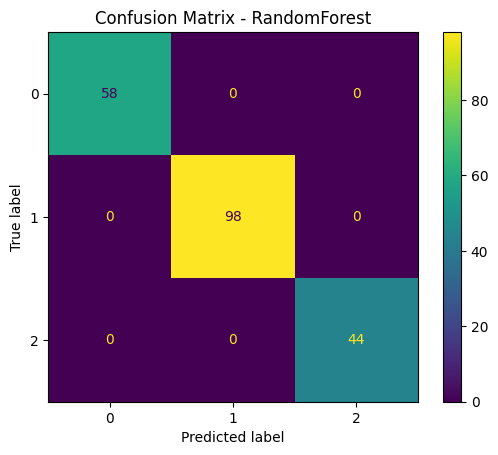

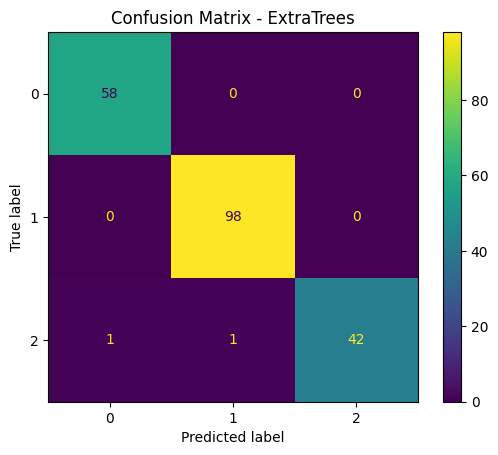

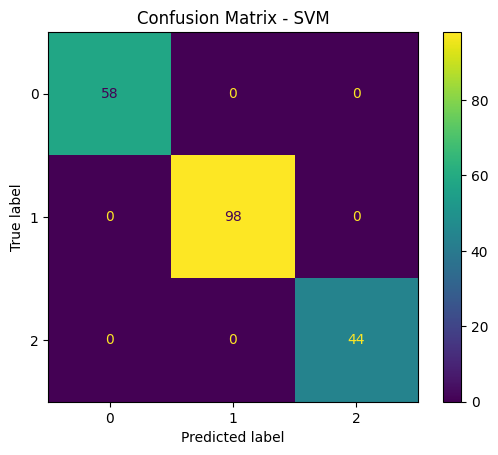

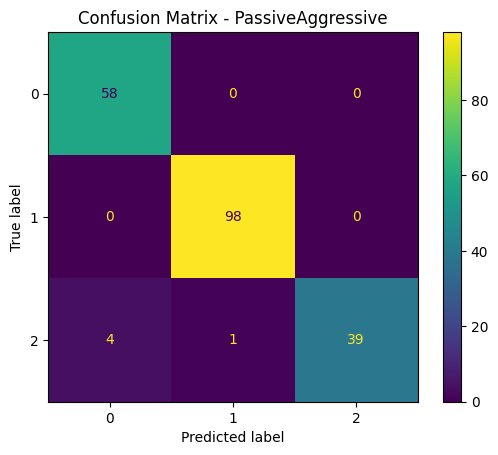

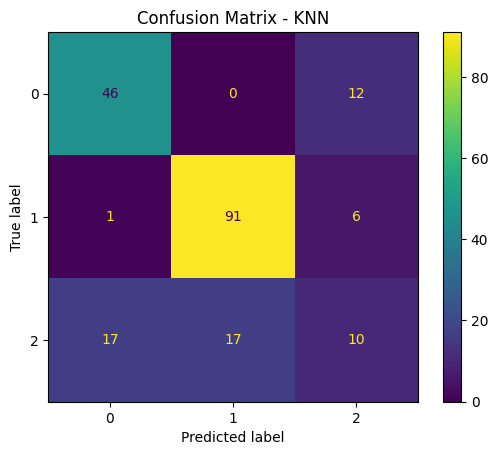

In [ ]:
# Display confusion matrices
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

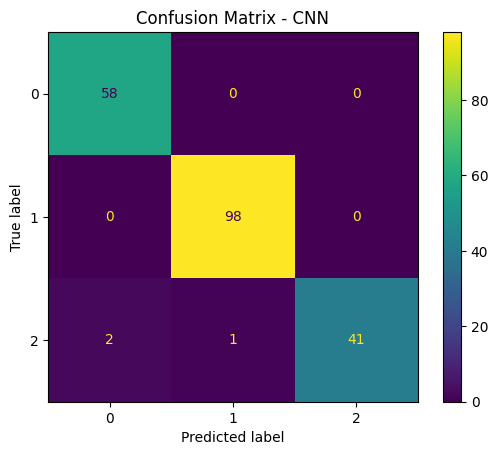

In [ ]:
# CNN confusion matrix
cm_cnn = confusion_matrix(y_test, y_pred_cnn)
disp_cnn = ConfusionMatrixDisplay(confusion_matrix=cm_cnn)
disp_cnn.plot()
plt.title("Confusion Matrix - CNN")
plt.show()

In [ ]:
# Final comparison DataFrame
results_df = pd.DataFrame(metrics_dict)
results_df.sort_values(by="Accuracy", ascending=False, inplace=True)
results_df.reset_index(drop=True, inplace=True)
results_df

,Model,Accuracy,Precision,Recall,F1,Hamming Loss,Log Loss
0,RandomForest,1.000,1.000000,1.000,1.000000,0.000,0.093408
1,SVM,1.000,1.000000,1.000,1.000000,0.000,0.032865
2,RandomForest,1.000,1.000000,1.000,1.000000,0.000,0.093408
3,SVM,1.000,1.000000,1.000,1.000000,0.000,0.032865
4,ExtraTrees,0.990,0.990135,0.990,0.989918,0.010,0.293452
5,ExtraTrees,0.990,0.990135,0.990,0.989918,0.010,0.293452
6,CNN,0.985,0.985384,0.985,0.984833,0.015,0.083086
7,PassiveAggressive,0.975,0.976341,0.975,0.974593,0.025,NaN
8,KNN,0.735,0.699879,0.735,0.712712,0.265,1.431537
